# Random Forest

Nesse notebook iremos treinar um modelo de Random Forest e iremos comparar seus resultados com os modelos treinados até aqui.

## Importando as Bibliotecas

Primeiro, vamos importar nossas bibliotecas.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

## Carregando o Dataset

Agora, vamos carregar o dataset.

In [2]:
df = pd.read_parquet("../../data/processed/03_processed.parquet")

In [3]:
df = df.convert_dtypes()

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 54 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   tipo_imovel                       7919 non-null   string  
 1   preco                             7919 non-null   Int64   
 2   condominio                        4602 non-null   Int64   
 3   area_m2                           7919 non-null   Int64   
 4   quartos                           7918 non-null   Int64   
 5   banheiros                         7918 non-null   Int64   
 6   vagas                             7286 non-null   Int64   
 7   piscina                           7919 non-null   boolean 
 8   espaco_gourmet                    7919 non-null   boolean 
 9   academia                          7919 non-null   boolean 
 10  spa_massagem                      7919 non-null   boolean 
 11  espaco_lazer                      7919 non-null   boolean 
 12  are

In [5]:
df.head(10)

,tipo_imovel,preco,condominio,area_m2,quartos,banheiros,vagas,piscina,espaco_gourmet,academia,...,distancia_aeroporto_km,faixa_area,faixa_condominio,m2_por_banheiro,m2_por_quarto,banheiros_por_m2,quartos_por_m2,banheiro_por_quarto,quarto_por_vaga,cluster
0,apartamento,350000,720,60,2,2,1,True,True,True,...,16.213545,pequeno,medio,30.0,30.0,0.033333,0.033333,1.0,2.0,4
1,apartamento,511914,<NA>,37,1,1,1,True,True,True,...,7.250204,pequeno,NaN,37.0,37.0,0.027027,0.027027,1.0,1.0,1
2,apartamento,980000,1037,125,3,5,2,True,True,False,...,8.381749,medio,alto,25.0,41.666667,0.04,0.024,1.666667,1.5,1
3,apartamento,2799000,1200,244,3,4,4,True,True,True,...,8.824588,grande,alto,61.0,81.333333,0.016393,0.012295,1.333333,0.75,14
4,apartamento,370000,460,57,2,2,1,True,True,True,...,9.267687,pequeno,medio,28.5,28.5,0.035088,0.035088,1.0,2.0,11
5,apartamento,499000,<NA>,55,2,2,1,True,True,True,...,4.911235,pequeno,NaN,27.5,27.5,0.036364,0.036364,1.0,2.0,7
6,apartamento,195000,350,52,1,1,<NA>,True,True,True,...,9.094186,pequeno,baixo,52.0,52.0,0.019231,0.019231,1.0,<NA>,8
7,apartamento,1210314,<NA>,128,3,3,2,True,True,True,...,6.613218,medio,NaN,42.666667,42.666667,0.023438,0.023438,1.0,1.5,1
8,apartamento,860000,880,105,3,4,2,True,True,True,...,7.747091,medio,alto,26.25,35.0,0.038095,0.028571,1.333333,1.5,1
9,apartamento,400000,400,55,2,2,1,True,True,True,...,3.412207,pequeno,baixo,27.5,27.5,0.036364,0.036364,1.0,2.0,7


## Divisão Treino-Teste

Nessa etapa de modelagem faremos otimização de hiperparâmetros dos nossos modelos e para checarmos a qualidade final do modelo iremos testâ-lo em dados de teste. Para isso precisamos dividir os dados de treinamento e de teste.

In [6]:
from sklearn.model_selection import train_test_split
from utils import random_state

X = df.drop("preco", axis="columns")
y = df["preco"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=random_state,
)

/home/gauloish/.dev/ds/projects/meu-ape/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Modelagem

O primeiro modelo que iremos treinar será o nosso baseline, uma regressão linear múltipla. Vamos inicialmente separar as features do nosso dataset baseado nos tipos delas.

In [7]:
discrete_columns = ["quartos", "banheiros", "vagas"]

continuous_columns = (X_train
    .drop(discrete_columns, axis="columns")
    .select_dtypes(include=["Int64", "Float64"])
    .columns
    .to_list()
)

ordinal_columns = (X_train
    .select_dtypes(include=["category"])
    .columns
    .to_list()
)

categorical_columns = (X_train
    .select_dtypes(include="string")
    .columns
    .to_list()
)

boolean_columns = (X_train
    .select_dtypes(include="boolean")
    .columns
    .to_list()
)

Agora, vamos montar o nosso pipeline de treinamento para a regressão linear.

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import QuantileTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
)
from sklearn.pipeline import Pipeline

from feature_engine.transformation import (
    LogCpTransformer,
    YeoJohnsonTransformer,
)

def get_random_forest_pipeline(parameters):
    imputer = SimpleImputer(strategy="median")
    imputer.set_output(transform="pandas")

    discrete_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    continuous_pipeline = Pipeline(steps=[
        ("imputer", imputer),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        )),
    ])

    ordinal_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder()),
    ])


    boolean_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("selector", TruncatedSVD(
            n_components=parameters["n_components"],
            random_state=random_state,
        ))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("continuous", continuous_pipeline, continuous_columns),
            ("discrete", discrete_pipeline, discrete_columns),
            ("categorical", categorical_pipeline, categorical_columns),
            ("ordinal", ordinal_pipeline, ordinal_columns),
            ("boolean", boolean_pipeline, boolean_columns),
        ],
        remainder="drop",
    )

    regressor = RandomForestRegressor(
        n_estimators=parameters["n_estimators"],
        max_depth=parameters["max_depth"],
        min_samples_split=parameters["min_samples_split"],
        min_samples_leaf=parameters["min_samples_leaf"],
        max_features=parameters["max_features"],
        random_state=random_state,
    )

    if parameters["transformer"] == "log":
        transformer = LogCpTransformer()

    elif parameters["transformer"] == "yeo_johnson":
        transformer = YeoJohnsonTransformer()

    elif parameters["transformer"] == "quantile":
        transformer = QuantileTransformer(
            output_distribution="normal",
            random_state=random_state,
        )

    if parameters["transformer"]:
        model = TransformedTargetRegressor(
            regressor=regressor,
            transformer=transformer,
        )
    else:
        model = regressor

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    return pipeline

def get_random_forest_parameters(trial):
    n_components = len(boolean_columns)

    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400, step=100),
        "max_depth": trial.suggest_int("max_depth", 10, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_float("max_features", 0.3, 1.0),
        "n_components": trial.suggest_int("n_components", 1, n_components),
        "transformer": trial.suggest_categorical("transformer", [
            "log",
            "yeo_johnson",
            "quantile",
            None
        ])
    }

In [9]:
import utils

study = utils.get_study(
    get_pipeline=get_random_forest_pipeline,
    get_parameters=get_random_forest_parameters,
    X_train=X_train,
    y_train=y_train,
    n_trials=1
)

[I 2026-08-23 17:14:27,002] A new study created in memory with name: no-name-b10a0d9f-574d-4244-838e-3b29504a1c27
Best trial: 0. Best value: -646524: 100%|██████████| 1/1 [01:24<00:00, 84.98s/it]

[I 2026-08-23 17:15:51,982] Trial 0 finished with value: -646524.454969771 and parameters: {'n_estimators': 400, 'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 0.6144375590224955, 'n_components': 21, 'transformer': None}. Best is trial 0 with value: -646524.454969771.


Vamos olhar as métricas do nosso modelo nos dados de treinamento.

In [16]:
utils.report_scores(
    get_pipeline=get_random_forest_pipeline,
    study=study,
    X=X_train,
    y=y_train
)

R2: 0.81
RMSE: R$ 646524.45
MAE: R$ 250764.15
MedAE: R$ 98950.52
MAPE: 0.22%


E agora nos dados de teste.

In [17]:
utils.report_scores(
    get_pipeline=get_random_forest_pipeline,
    study=study,
    X=X_test,
    y=y_test
)

R2: 0.73
RMSE: R$ 750019.57
MAE: R$ 326556.20
MedAE: R$ 121985.56
MAPE: 0.29%


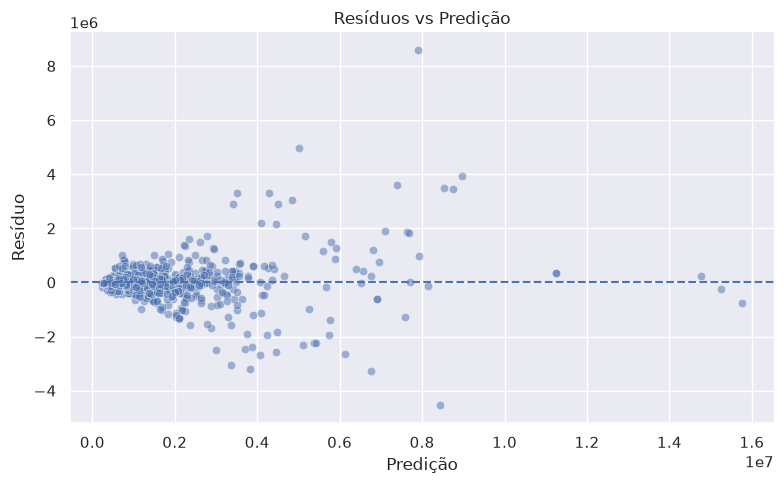

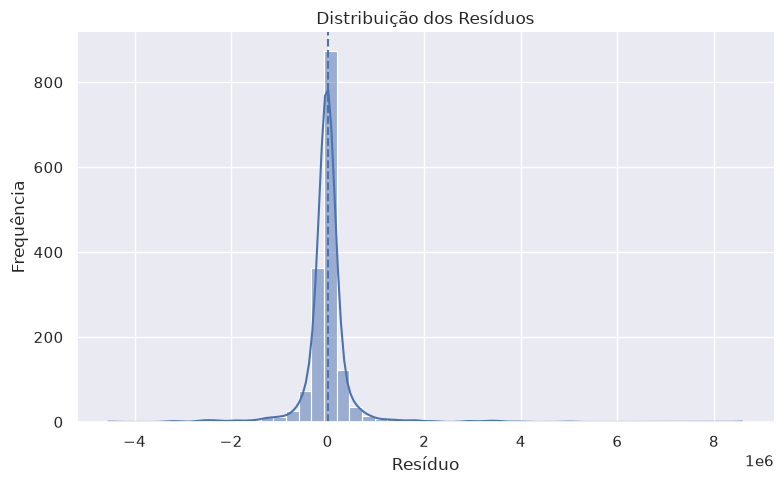

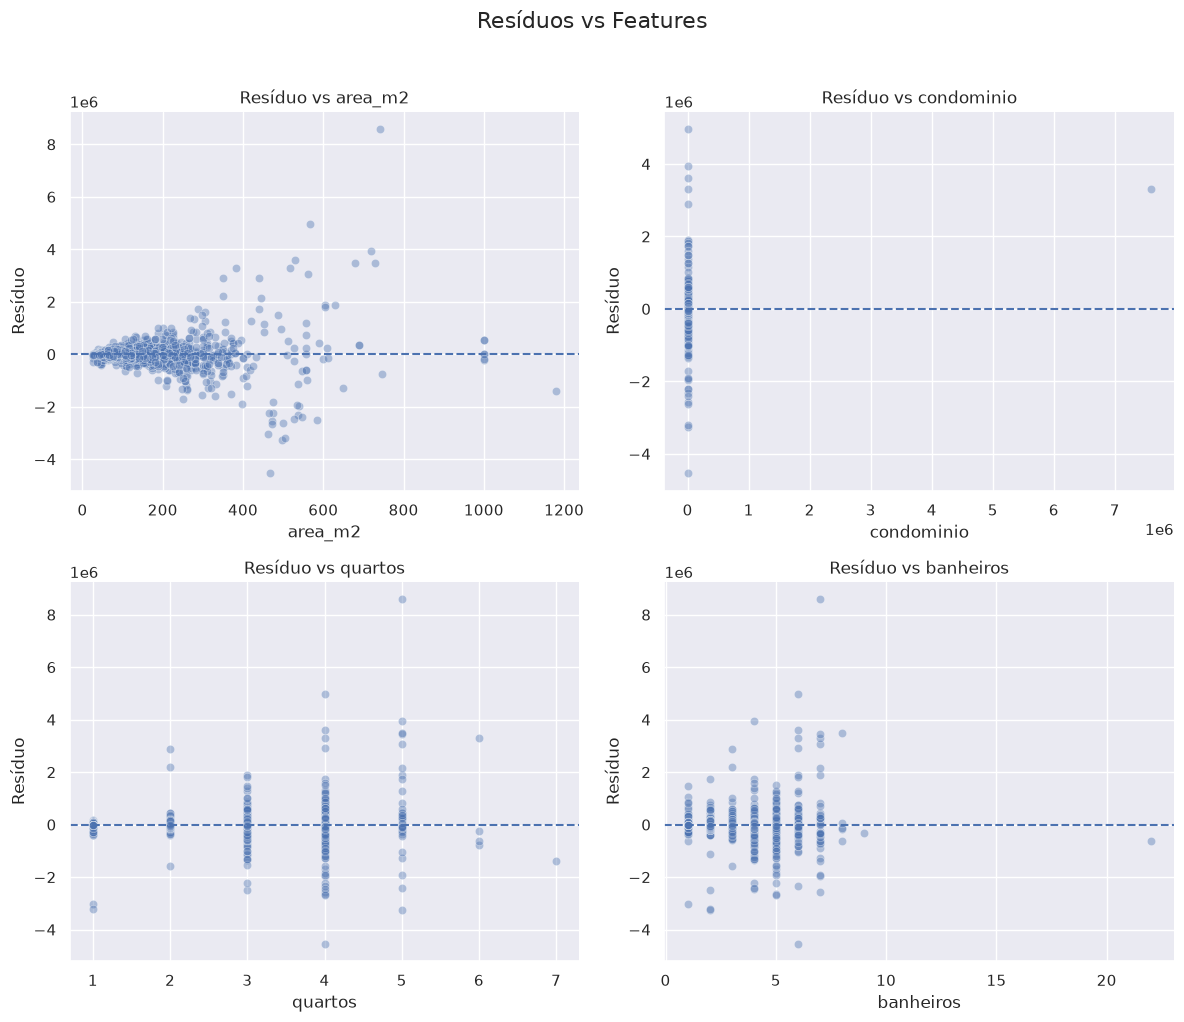

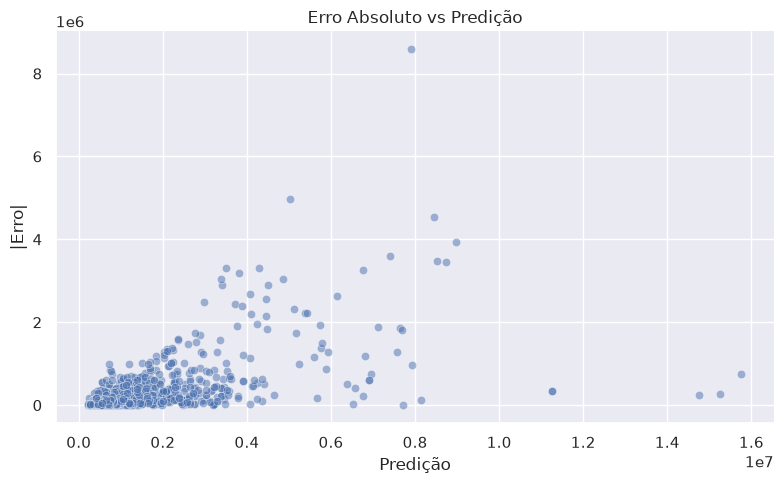


=== Erro Relativo Absoluto ===
count      1584.0
mean     0.228098
std      0.437296
min      0.000043
25%      0.056873
50%      0.129272
75%      0.246195
max      9.072276
Name: absolute_relative_error, dtype: Float64

=== 20 Maiores Erros Absolutos ===
      tipo_imovel  condominio  area_m2  quartos  banheiros  vagas  piscina  espaco_gourmet  academia  spa_massagem  espaco_lazer  area_trabalho  espaco_infantil  area_esportiva  portaria  seguranca  servicos_garagem  acessibilidade   pets  varanda  area_verde  espaco_natural  acabamento_premium  moveis_embutidos  layout_premium  cozinha  servicos  conforto_interno  mobiliado  casa_inteligente  servicos_conectividade  infra_energetica  infra_hidrica  servicos_sustentaveis   latitude  longitude  distancia_flamboyant_shopping_km  distancia_goiania_shopping_km  distancia_passeio_das_aguas_km  distancia_setor_central_km  distancia_setor_bueno_km  distancia_setor_marista_km  distancia_jardim_goias_km  distancia_aeroporto_km    faixa_area 

In [14]:
linear_regression_error_df = utils.get_residual_analysis(
    get_pipeline=get_random_forest_pipeline,
    study=study,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)